<table align="center" width=100%>
    <tr>
        <td width="15%">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=24px>
                    <b>Insurance Premium Prediction According to customer risk
                    </b>
                </font>
        </td>
    </tr>
</table>

## Problem Statement
A key challenge for the insurance industry is to charge each customer an appropriate premium for the risk they represent. The ability to predict a correct claim amount has a significant impact on insurer's management decisions and financial statements. Predicting the cost of claims in an insurance company is a real-life problem that needs to be solved in a more accurate and automated way. Several factors determine the cost of claims based on health factors like BMI, age, smoker, health conditions and others. Insurance companies apply numerous techniques for analyzing and predicting health insurance costs

## Data Definition

**age** : Age of the policyholder (Numeric)

**sex:** Gender of policyholder (Categoric)

**weight:** Weight of the policyholder (Numeric)

**bmi**: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight (Numeric)

**no_of_dependents:** Number of dependent persons on the policyholder (Numeric)

**smoker:** Indicates policyholder is a smoker or a non-smoker (non-smoker=0;smoker=1) (Categoric)

**claim:** The amount claimed by the policyholder (Numeric)

**bloodpressure:** Bloodpressure reading of policyholder (Numeric)

**diabetes:** Indicates policyholder suffers from diabetes or not (non-diabetic=0; diabetic=1) (Categoric)

**regular_ex:** A policyholder regularly excercises or not (no-excercise=0; excercise=1) (Categoric)

**job_title:** Job profile of the policyholder (Categoric)

**city:** The city in which the policyholder resides (Categoric)

**hereditary_diseases:**  A policyholder suffering from a hereditary diseases or not (Categoric)

<a id='import_lib'></a>
## 1. Import Libraries

In [115]:
# supress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# 'Os' module provides functions for interacting with the operating system 
import os

# 'Pandas' is used for data manipulation and analysis
import pandas as pd 

# 'Numpy' is used for mathematical operations on large, multi-dimensional arrays and matrices
import numpy as np

# 'Matplotlib' is a data visualization library for 2D and 3D plots, built on numpy
import matplotlib.pyplot as plt
%matplotlib inline

# 'Seaborn' is based on matplotlib; used for plotting statistical graphics
import seaborn as sns

# 'Scikit-learn' (sklearn) emphasizes various regression, classification and clustering algorithms
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso,ElasticNet
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
# 'Statsmodels' is used to build and analyze various statistical models
import statsmodels
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.tools.eval_measures import rmse
from statsmodels.compat import lzip
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

# 'SciPy' is used to perform scientific computations
from scipy.stats import f_oneway
from scipy.stats import jarque_bera
from scipy import stats

<a id='set_options'></a>
## 2. Set Options

In [2]:
# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None

# return an output value upto 6 decimals
pd.options.display.float_format = '{:.2f}'.format

<a id='Read_Data'></a>
## 3. Read Data

In [130]:
# read csv file using pandas
df_insurance = pd.read_csv("healthinsurance.csv")

# display the top 5 rows of the dataframe
df_insurance.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.00,male,64,24.30,NoDisease,1,0,NewYork,72,0,0,Actor,13112.60
1,49.00,female,75,22.60,NoDisease,1,0,Boston,78,1,1,Engineer,9567.00
2,32.00,female,64,17.80,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.20
3,61.00,female,53,36.40,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.60
4,19.00,female,50,20.60,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.70


<a id='data_preparation'></a>
## 4. Data Analysis and Preparation


<a id='Data_Understanding'></a>
### 4.1 Understand the Dataset

<a id='Data_Shape'></a>
### 4.1.1 Data Dimension

In [131]:
df_insurance.shape

(15000, 13)

### 4.1.2 Data Types


**1. Check data types**

In [132]:
df_insurance.dtypes

age                    float64
sex                     object
weight                   int64
bmi                    float64
hereditary_diseases     object
no_of_dependents         int64
smoker                   int64
city                    object
bloodpressure            int64
diabetes                 int64
regular_ex               int64
job_title               object
claim                  float64
dtype: object

**2. Change the incorrect data types**

In [133]:
# use .astype() to change the data type
# convert numerical variables to categorical  

# convert numeric variable 'smoker' to object (categorical) variable
df_insurance.smoker = df_insurance.smoker.astype('object')       # or .astype('O')

# convert numeric variable 'diabetes' to object (categorical) variable
df_insurance.diabetes = df_insurance.diabetes.astype('object')

# convert 'regular_ex' variable diabetes to object (categorical) variable
df_insurance.regular_ex = df_insurance.regular_ex.astype('object')

**3. Recheck the data types after the conversion**

In [134]:
# recheck the data types using .dtypes
df_insurance.dtypes

age                    float64
sex                     object
weight                   int64
bmi                    float64
hereditary_diseases     object
no_of_dependents         int64
smoker                  object
city                    object
bloodpressure            int64
diabetes                object
regular_ex              object
job_title               object
claim                  float64
dtype: object

Note the data types are now as per the data definition. Now we can proceed with the analysis.

<a id='Summary_Statistics'></a>
### 4.1.3 Summary Statistics

In [135]:
# describe the numerical data
df_insurance.describe()

,age,weight,bmi,no_of_dependents,bloodpressure,claim
count,14604.00,15000.00,14044.00,15000.00,15000.00,15000.00
mean,39.55,64.91,30.27,1.13,68.65,13401.44
std,14.02,13.70,6.12,1.23,19.42,12148.24
min,18.00,34.00,16.00,0.00,0.00,1121.90
25%,27.00,54.00,25.70,0.00,64.00,4846.90
50%,40.00,63.00,29.40,1.00,71.00,9545.65
75%,52.00,76.00,34.40,2.00,80.00,16519.12
max,64.00,95.00,53.10,5.00,122.00,63770.40


**2. For categorical features, we use .describe(include=object)**

In [136]:
# describe the categorical data
# include=object: selects the categorical features
df_insurance.describe(include = object)


,sex,hereditary_diseases,smoker,city,diabetes,regular_ex,job_title
count,15000,15000,15000,15000,15000,15000,15000
unique,2,10,2,91,2,2,35
top,female,NoDisease,0,NewOrleans,1,0,Student
freq,7652,13998,12028,302,11655,11638,1320


<a id='Missing_Values'></a>
### 4.1.4 Missing Values

In [140]:
# Find total missing values
Total = df_insurance.isnull().sum().sort_values(ascending=False) 
Total

bmi                    956
age                    396
sex                      0
weight                   0
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

In [11]:
# Find percent missing values
Percent = (df_insurance.isnull().sum()*100/df_insurance.isnull().count()).sort_values(ascending=False)   

# concat the 'Total' and 'Percent' columns using 'concat' function
missing_data = pd.concat([Total, Percent], axis = 1, keys = ['Total', 'Percentage of Missing Values'])

# print the missing data
missing_data

,Total,Percentage of Missing Values
bmi,956,6.37
age,396,2.64
sex,0,0.00
weight,0,0.00
hereditary_diseases,0,0.00
no_of_dependents,0,0.00
smoker,0,0.00
city,0,0.00
bloodpressure,0,0.00
diabetes,0,0.00


The missing values are present in the data for the `age` and `bmi` variables. There are 396 (2.6%) missing values for the variable `age` and 956 (6.4%) missing values for the variable `bmi`

### Deal with Missing Values

Discuss - How to deal with missing data?<br>


In [12]:
# check the average age for male and female

df_insurance['age'].groupby(df_insurance['sex'], axis=0).mean()

sex
female   39.36
male     39.74
Name: age, dtype: float64

The average age for the male and female is nearly the same. We will fill in missing values with the mean age of the policyholder.

In [13]:
# fill the missing values with the mean value of 'age' using 'fillna()'
df_insurance['age'].fillna(df_insurance['age'].mean(), inplace=True)

Replace missing values by mean for the BMI.

In [14]:
# fill the missing values with the mean value of 'bmi' using 'fillna()'

df_insurance['bmi'].fillna(df_insurance['bmi'].mean(), inplace=True)

We have seen that the the minimum bloodpressure is 0, which is absurd. It implies that these are missing values. 
Let us replace these missing values with the median value.

In [15]:
# calculate the median of the bloodpressure using 'median()''
median_bloodpressure = df_insurance['bloodpressure'].median()

# replace zero values by median using 'replace()'
df_insurance['bloodpressure'] = df_insurance['bloodpressure'].replace(0,median_bloodpressure) 

Recheck the summary statistics to confirm the missing value treatment for the variable 'bloodpressure'.

In [16]:
# obtain the summary statistics of numeric variables using 'describe()'
df_insurance.describe()

,age,weight,bmi,no_of_dependents,bloodpressure,claim
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,39.55,64.91,30.27,1.13,72.23,13401.44
std,13.83,13.70,5.92,1.23,11.27,12148.24
min,18.00,34.00,16.00,0.00,40.00,1121.90
25%,27.00,54.00,25.90,0.00,64.00,4846.90
50%,40.00,63.00,29.80,1.00,71.00,9545.65
75%,51.00,76.00,34.10,2.00,80.00,16519.12
max,64.00,95.00,53.10,5.00,122.00,63770.40


To confirm the data is valid, observe the minimum and maximum value of the variable `bloodpressure` is 40

<a id='correlation'></a>
### 4.1.5 Correlation

In [17]:

df_numeric_features = df_insurance.select_dtypes(include=np.number)
df_numeric_features.columns

Index(['age', 'weight', 'bmi', 'no_of_dependents', 'bloodpressure', 'claim'], dtype='object')

In [18]:
# generate the correlation matrix
corr =  df_numeric_features.corr()
corr

,age,weight,bmi,no_of_dependents,bloodpressure,claim
age,1.00,0.28,0.18,0.06,0.02,0.30
weight,0.28,1.00,0.24,0.14,0.02,0.08
bmi,0.18,0.24,1.00,0.05,-0.05,0.20
no_of_dependents,0.06,0.14,0.05,1.00,0.04,0.07
bloodpressure,0.02,0.02,-0.05,0.04,1.00,0.04
claim,0.30,0.08,0.20,0.07,0.04,1.00


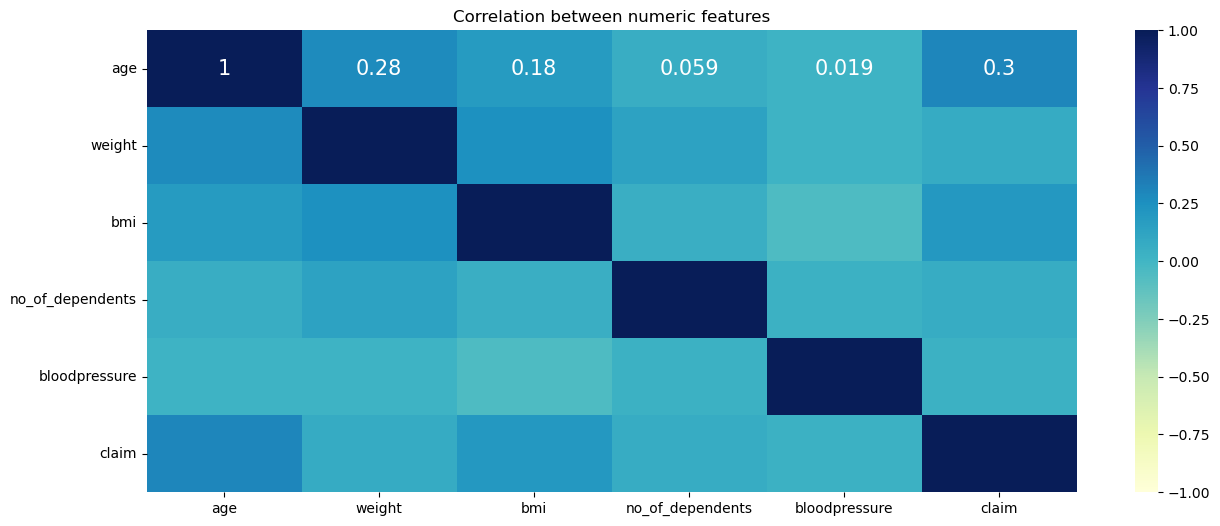

In [19]:
# set the figure size
plt.figure(figsize=(15, 6))

sns.heatmap(corr, cmap='YlGnBu', vmax=1.0, vmin=-1.0, annot = True, annot_kws={"size": 15}, )
plt.title('Correlation between numeric features')
plt.show()

<a id='categorical'></a>
### 4.1.6 Analyze Categorical Variables



In [20]:
df_insurance.describe(include=object)

,sex,hereditary_diseases,smoker,city,diabetes,regular_ex,job_title
count,15000,15000,15000,15000,15000,15000,15000
unique,2,10,2,91,2,2,35
top,female,NoDisease,0,NewOrleans,1,0,Student
freq,7652,13998,12028,302,11655,11638,1320


There are 6 categorical variables. From the output we see that the variable cities has most number of categories. There are 91 cities in the data, of which NewOrleans occurs highes number of times.

Let us visualize the variables. However, we shall exculde the variable `city` from it.

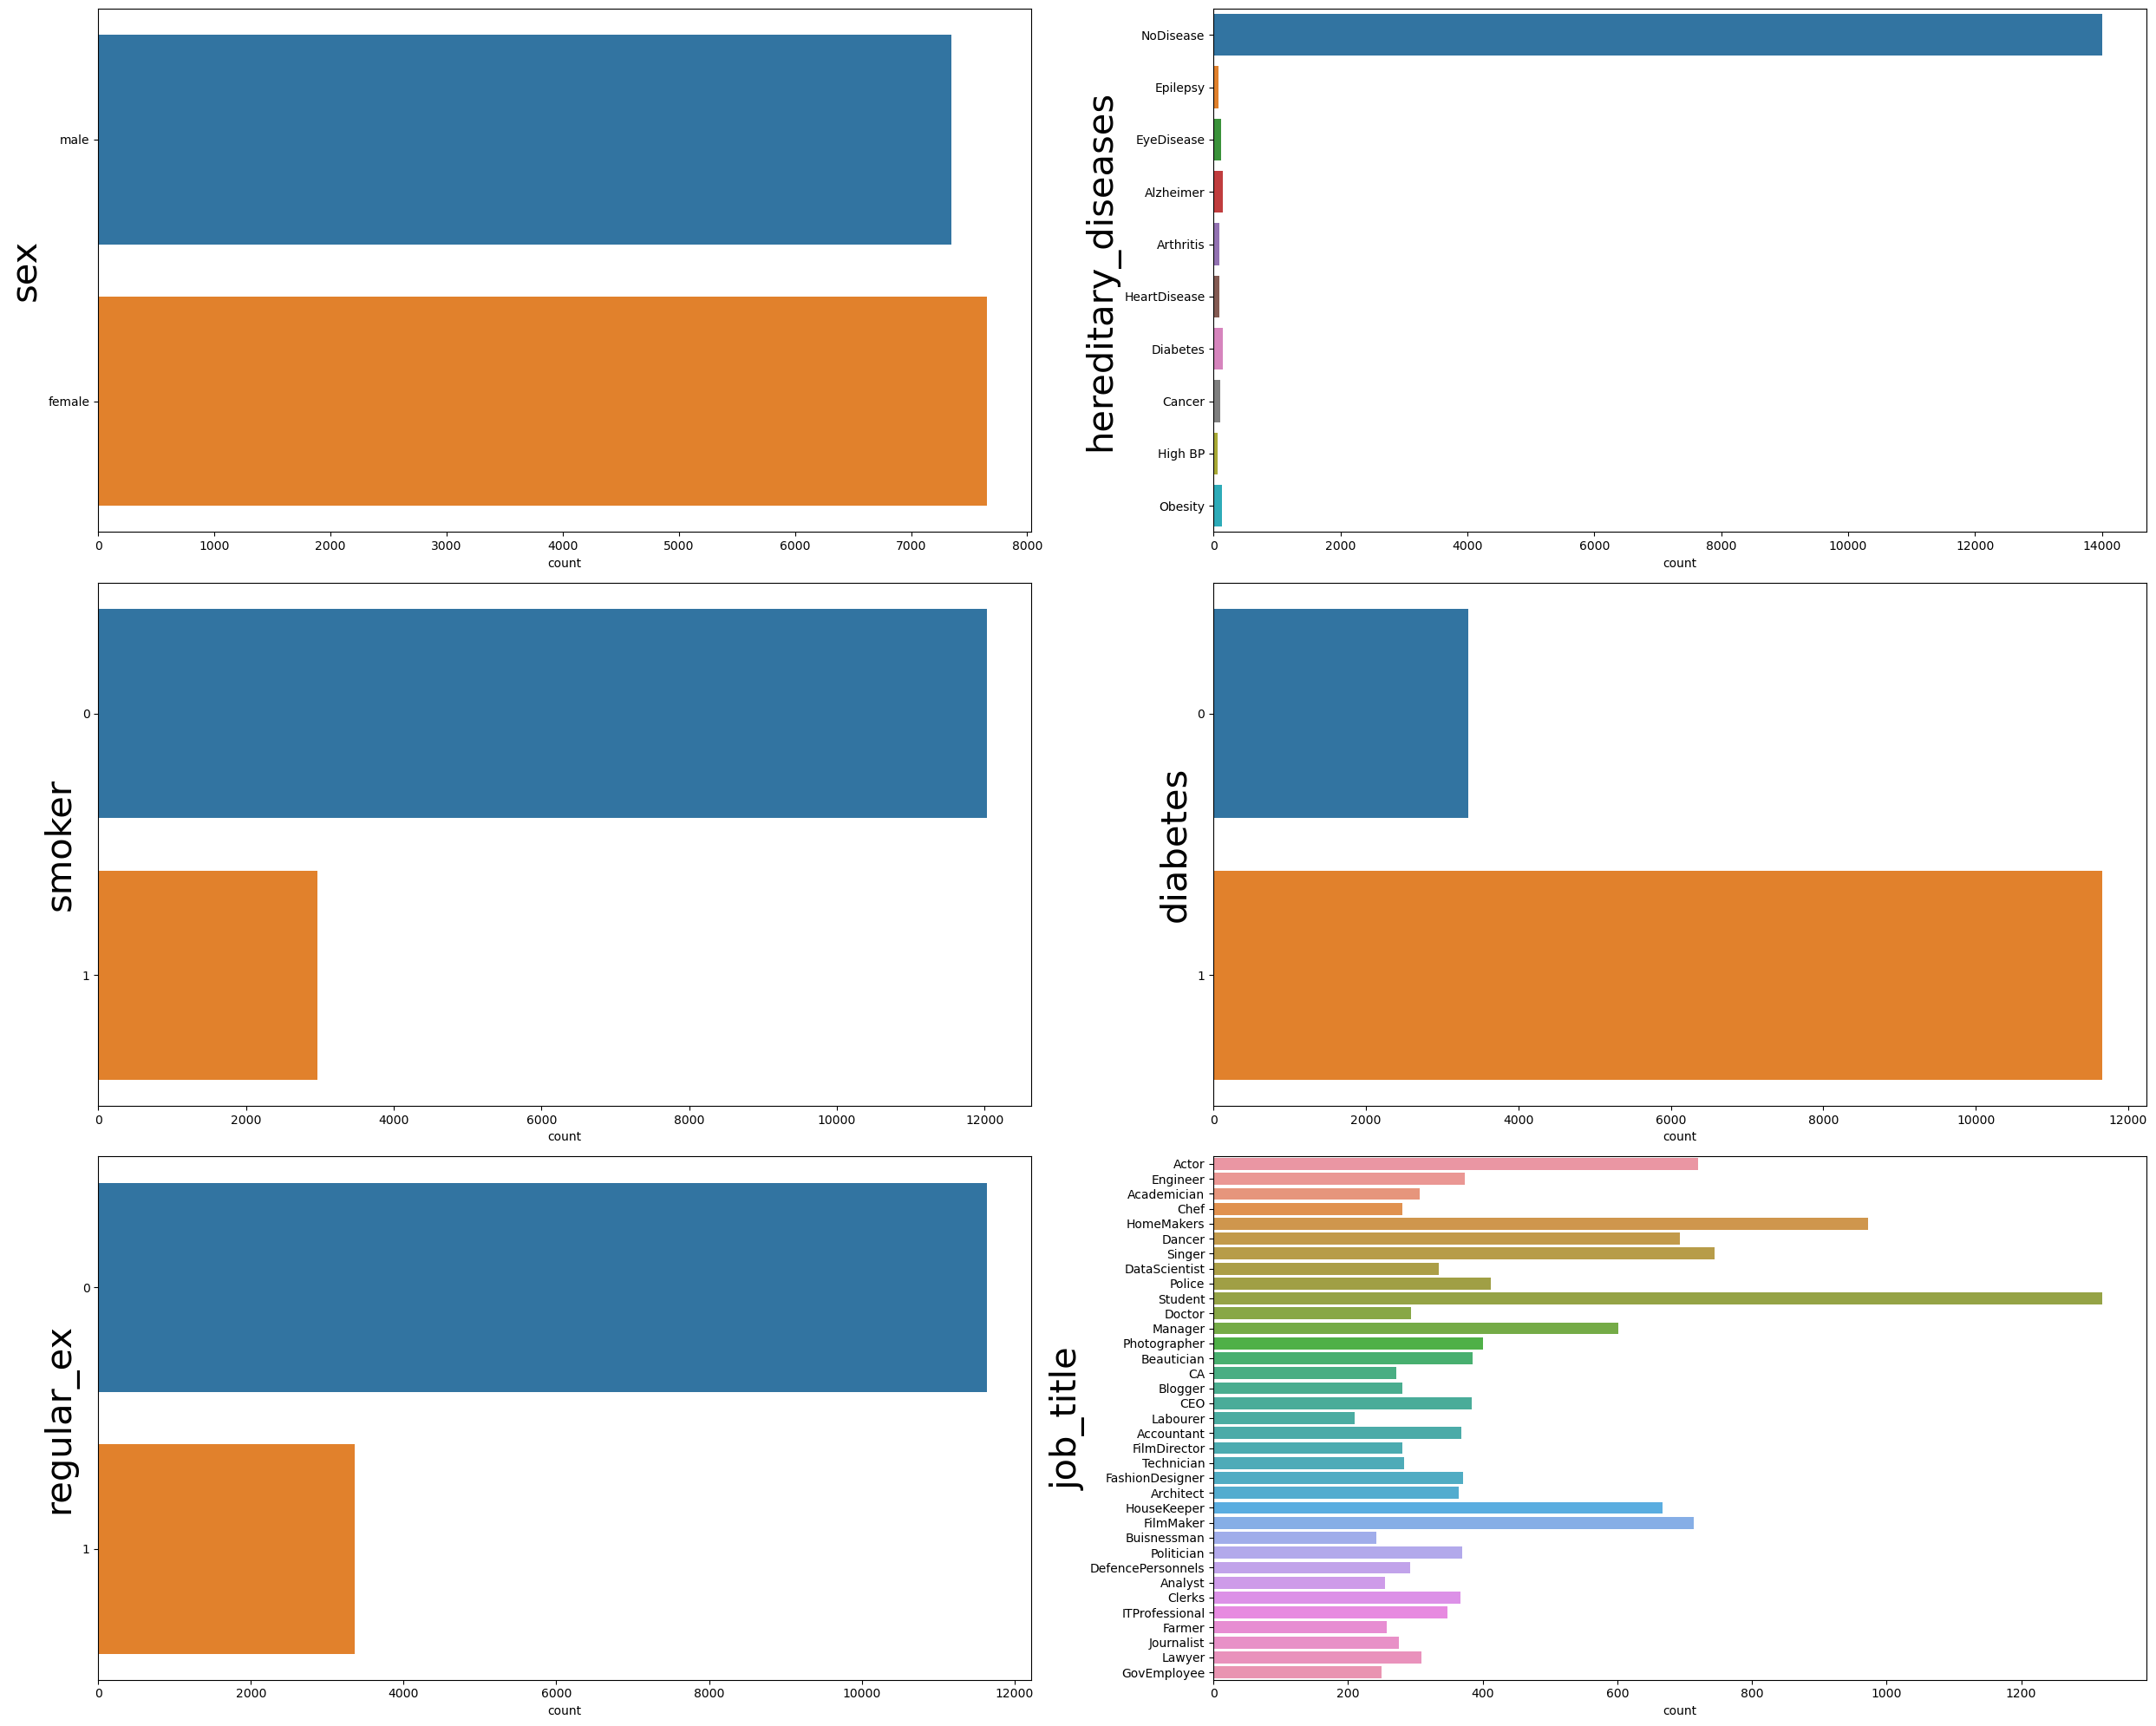

In [21]:
# create a list of all categorical variables
df_categoric_features = df_insurance.select_dtypes(include='object').drop(['city'], axis=1)

# plot the count distribution for each categorical variable 
# 'figsize' sets the figure size
fig, ax = plt.subplots(3, 2, figsize=(25, 20))

# plot a count plot for all the categorical variables
for variable, subplot in zip(df_categoric_features, ax.flatten()):
    
    countplot = sns.countplot(y=df_insurance[variable], ax=subplot )
       
    countplot.set_ylabel(variable, fontsize = 30)

plt.tight_layout()   
plt.show()

Now consider the variable `city`.

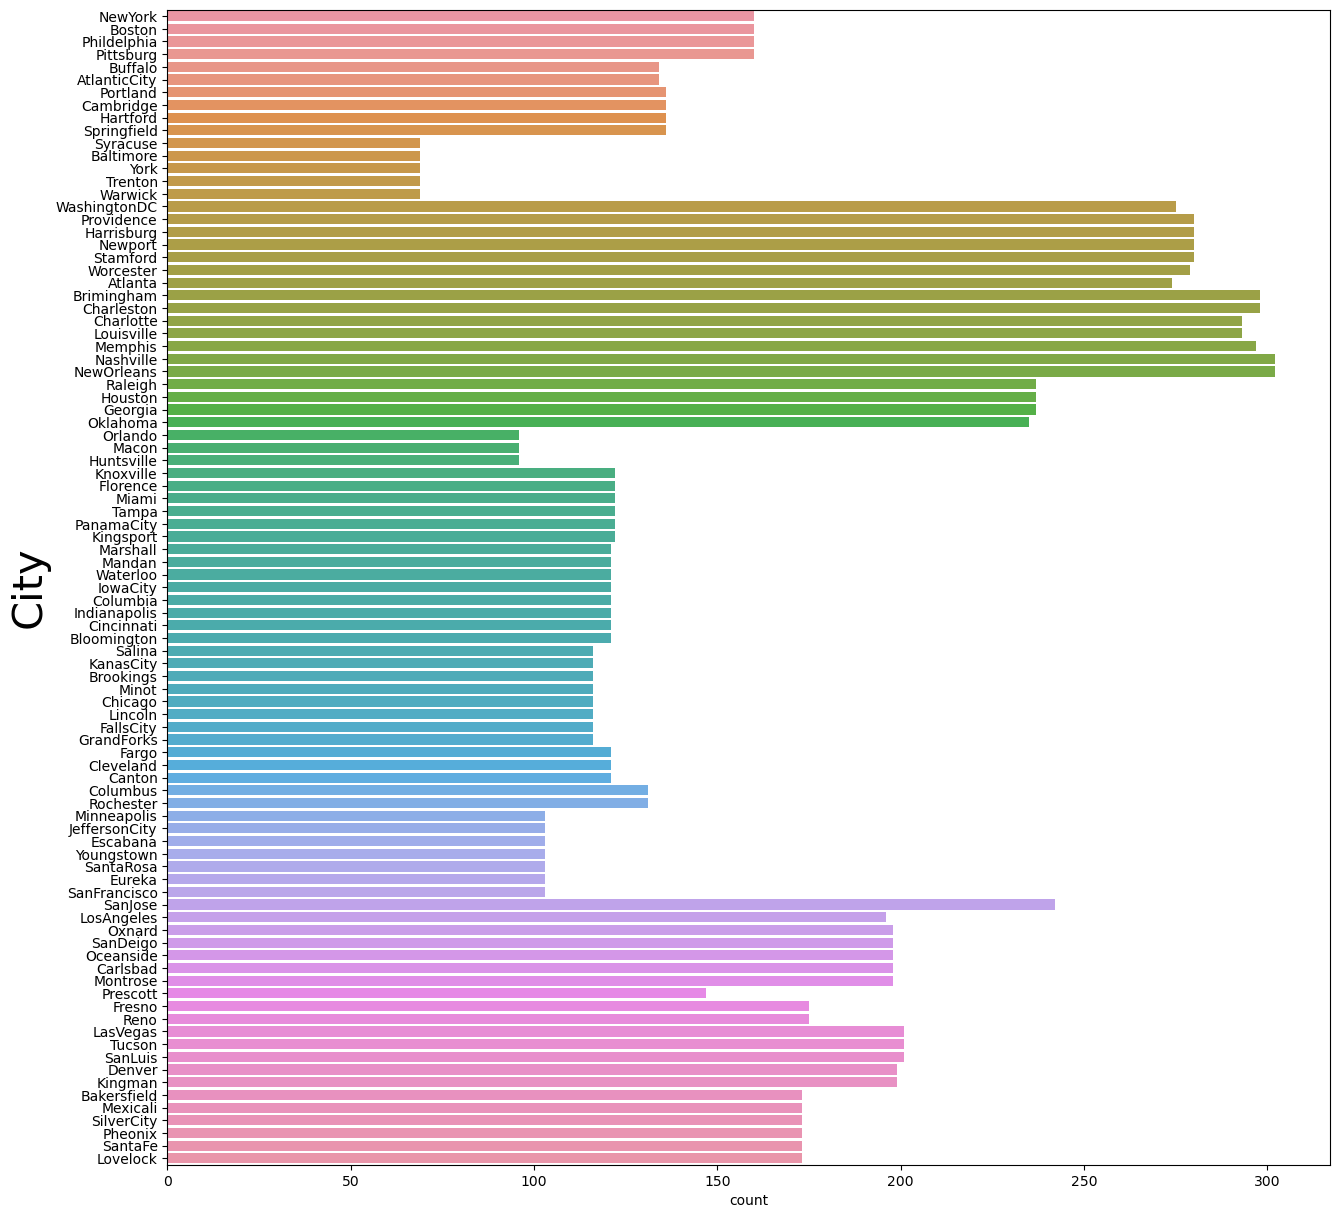

In [22]:
# set the figure size
plt.figure(figsize=(15, 15))
countplot = sns.countplot(y=df_insurance['city'], orient="h")
countplot.set_ylabel('City', fontsize = 30)
plt.show()

### 4.1.7 Analyze Relationship Between Target and Categorical Variables

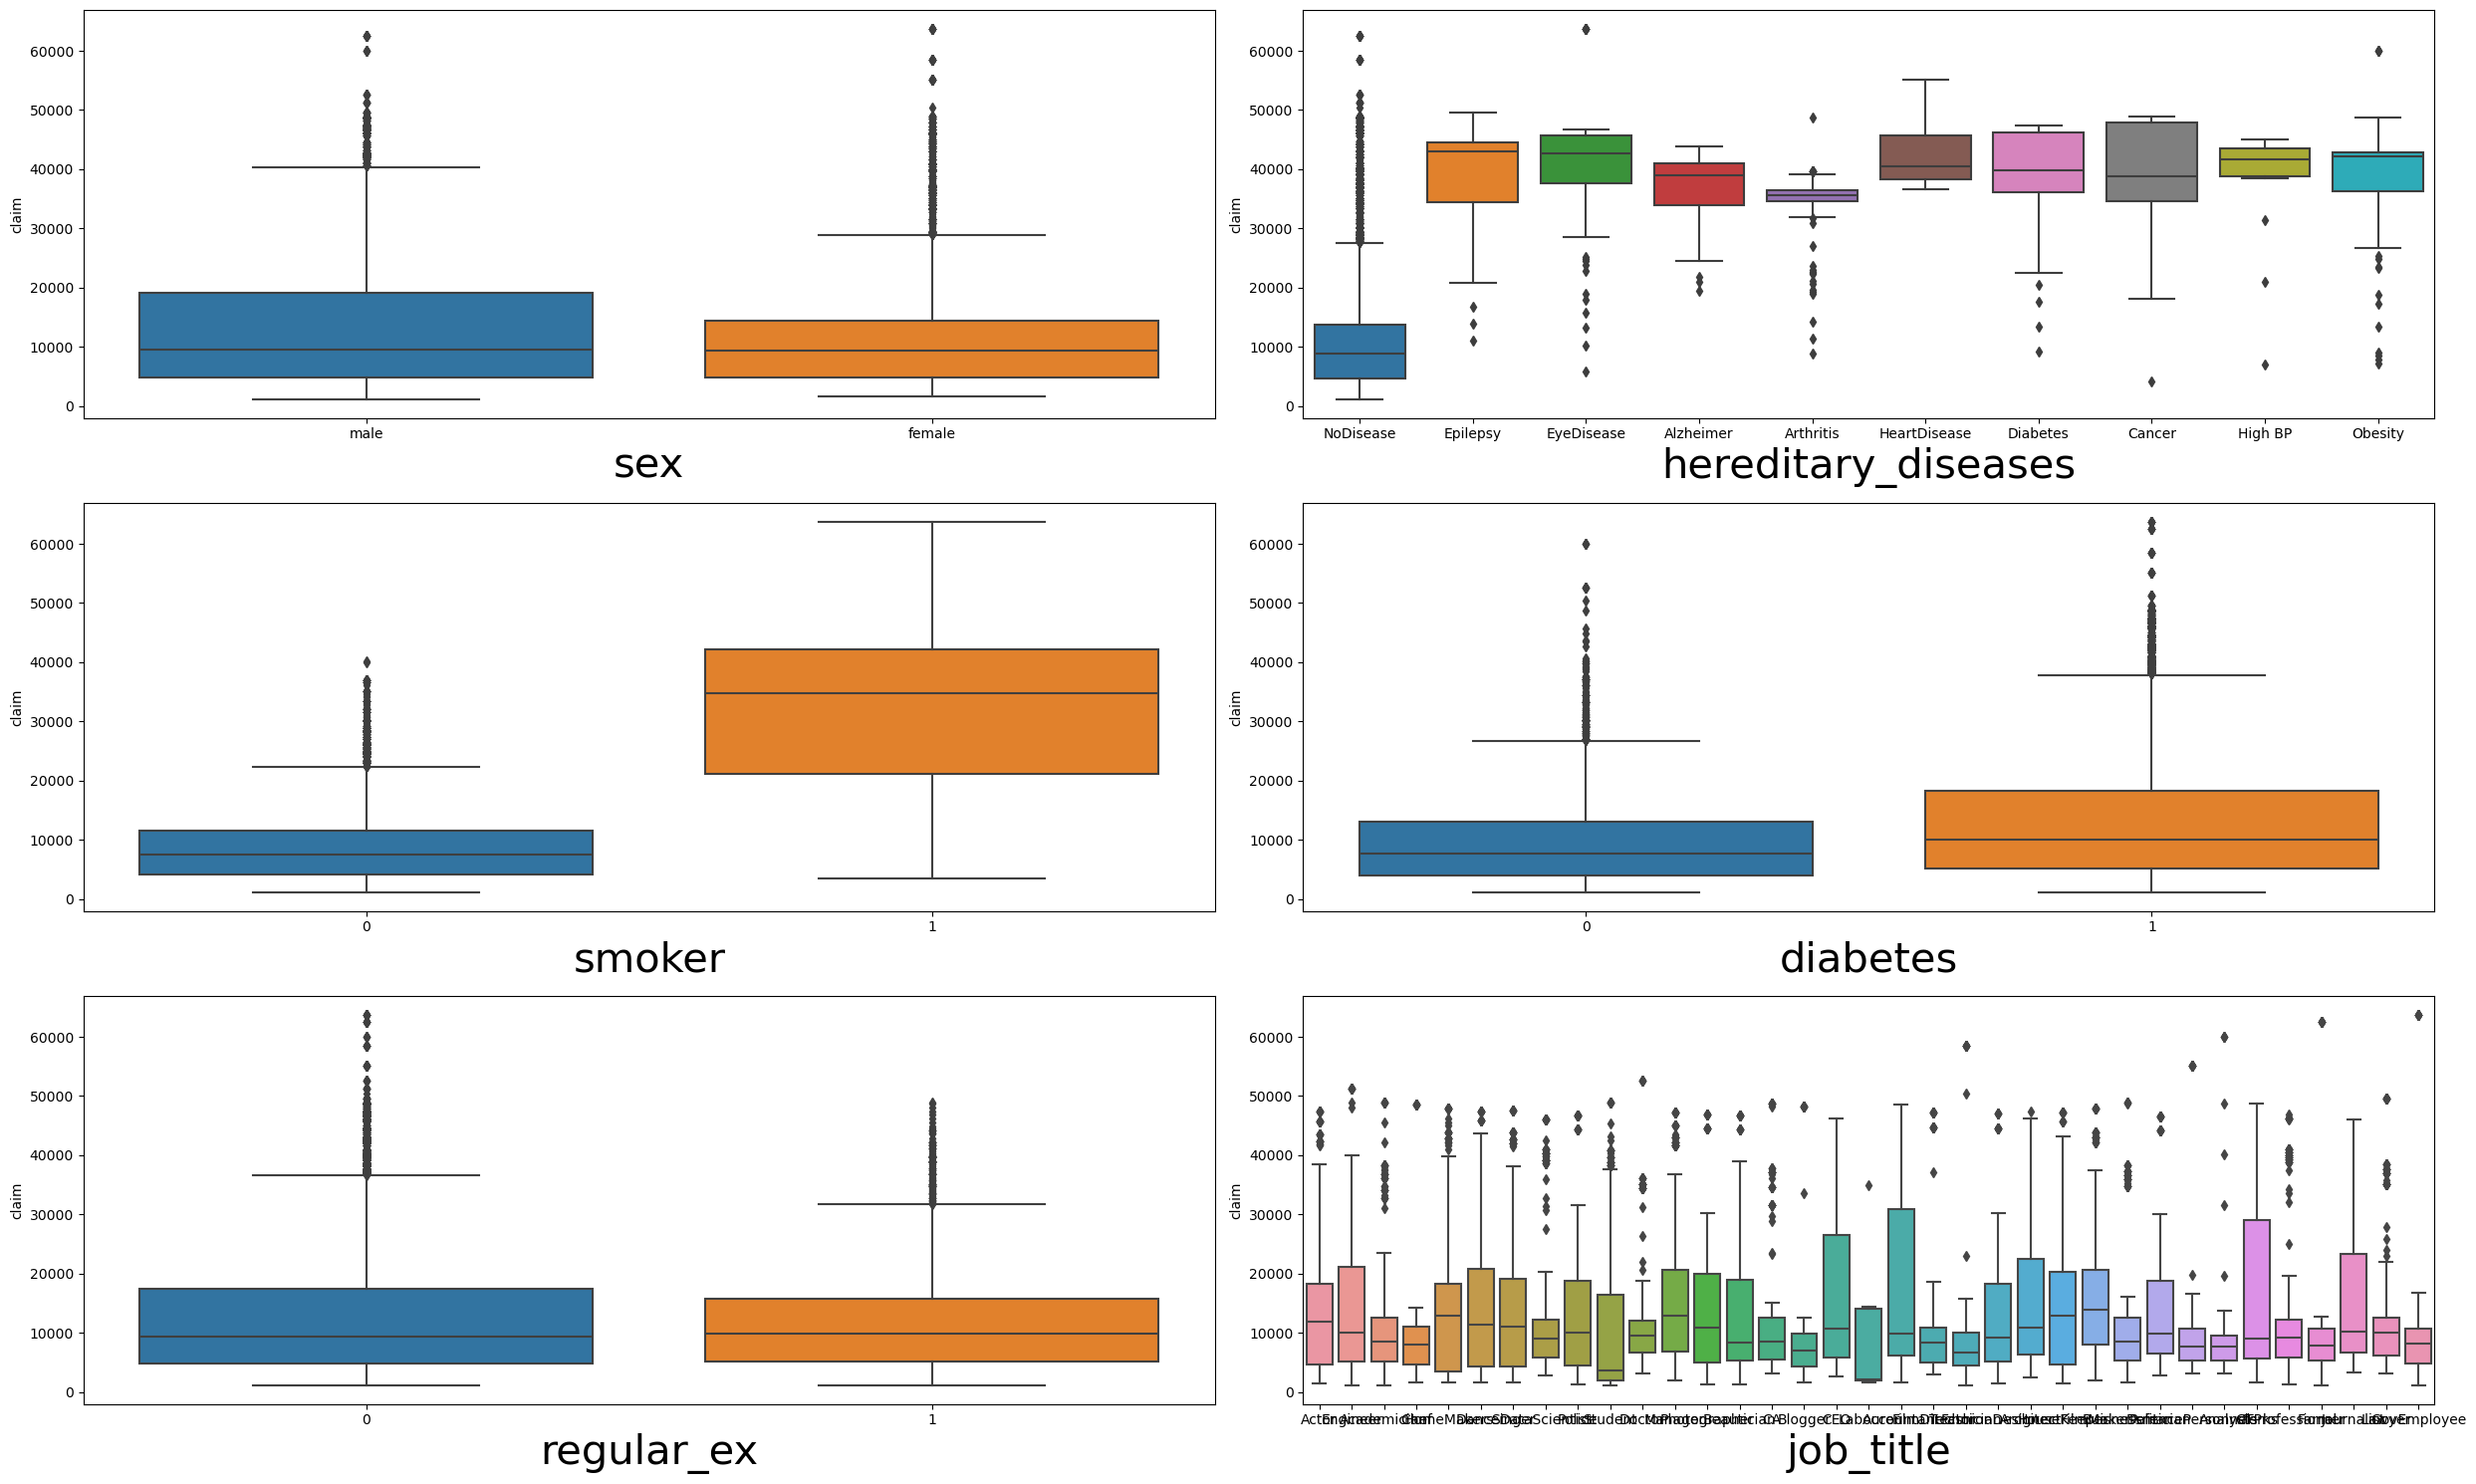

In [23]:
# plot the boxplot for each categorical variable 
# create subplots using subplots()
# 6 subplots in 3 rows and 2 columns
# 'figsize' sets the figure size
fig, ax = plt.subplots(3, 2, figsize=(25, 15))

# plot a boxplot for all the categorical variables 
for variable, subplot in zip(df_categoric_features, ax.flatten()):
    
    # x: variable on x-axis
    # y: variable in y-axis
    # data: dataframe to be used
    # ax: specifies the axes object to draw the plot onto
    boxplt = sns.boxplot(x=variable, y='claim', data=df_insurance, ax=subplot)
    
    # set the x-axis labels 
    # fontsize = 30: sets the font size to 30
    boxplt.set_xlabel(variable, fontsize = 30)

# avoid overlapping of the plots using tight_layout()    
plt.tight_layout()   

# display the plot
plt.show() 

Since the variable `city` has 91 categories, we shall plot it separately.

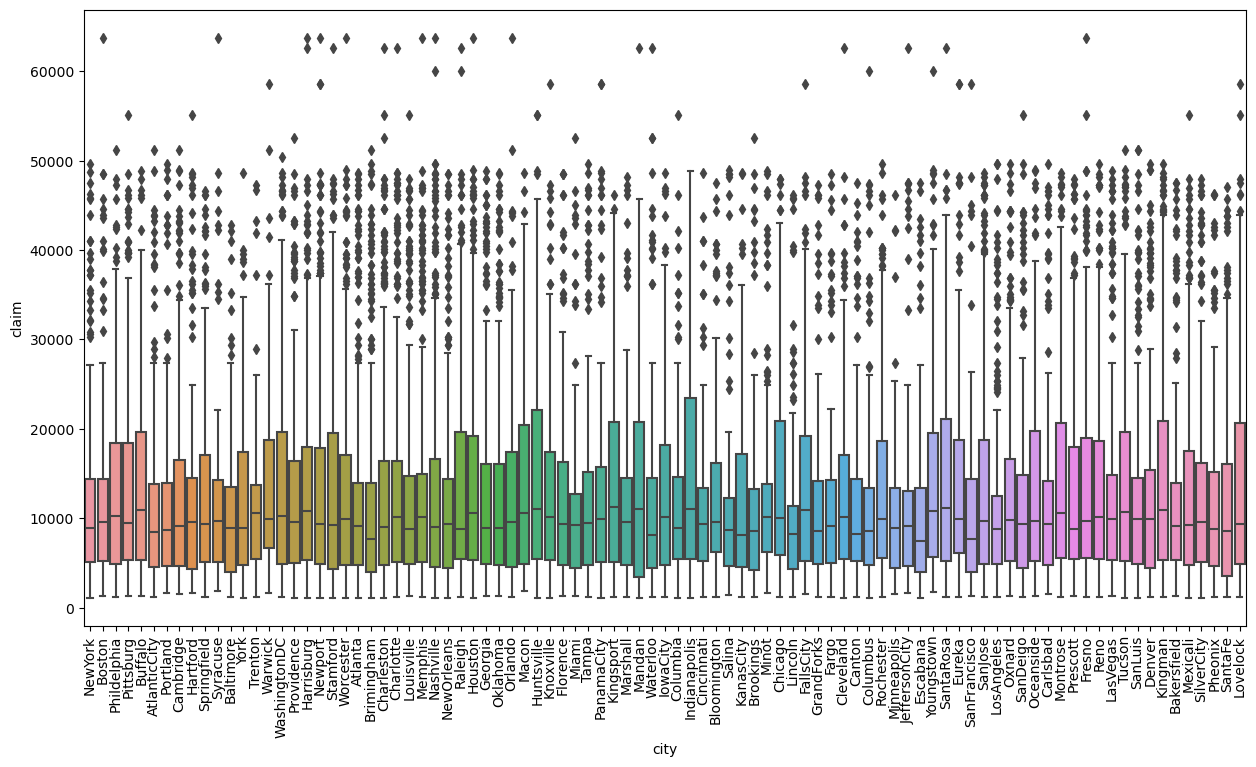

In [24]:
# set the figure size
plt.figure(figsize=(15, 8))

# plot the boxplot for categorical variable 'city'

ax = sns.boxplot(x=df_insurance["city"], y=df_insurance['claim'], data=df_insurance)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize = 10)
plt.show()

<a id='Feature_Engineering'></a>
### 4.1.8 Feature Engineering

Create a new feature 'region' by combining the cities.

**There are 91 unique cities. We will divide these cities into North-East, West, Mid-West, and South regions.**

Let's create a new variable region. We will replace the original variable `city` with it.

In [25]:
# create a region column and combine the north-east cities
df_insurance['region'] = df_insurance['city'].replace(['NewYork', 'Boston', 'Phildelphia', 'Pittsburg', 'Buffalo',
                                                       'AtlanticCity','Portland', 'Cambridge', 'Hartford', 
                                                       'Springfield', 'Syracuse', 'Baltimore', 'York', 'Trenton',
                                                       'Warwick', 'WashingtonDC', 'Providence', 'Harrisburg',
                                                       'Newport', 'Stamford', 'Worcester'],
                                                      'North-East')

In [26]:
# combine all the southern cities into the 'region' column
df_insurance['region'] = df_insurance['region'].replace(['Atlanta', 'Brimingham', 'Charleston', 'Charlotte',
                                                         'Louisville', 'Memphis', 'Nashville', 'NewOrleans',
                                                         'Raleigh', 'Houston', 'Georgia', 'Oklahoma', 'Orlando',
                                                         'Macon', 'Huntsville', 'Knoxville', 'Florence', 'Miami',
                                                         'Tampa', 'PanamaCity', 'Kingsport', 'Marshall'],
                                                         'Southern')

In [27]:
# combine all the mid-west cities into the 'region' column
df_insurance['region'] = df_insurance['region'].replace(['Mandan', 'Waterloo', 'IowaCity', 'Columbia',
                                                         'Indianapolis', 'Cincinnati', 'Bloomington', 'Salina',
                                                         'KanasCity', 'Brookings', 'Minot', 'Chicago', 'Lincoln',
                                                         'FallsCity', 'GrandForks', 'Fargo', 'Cleveland', 
                                                         'Canton', 'Columbus', 'Rochester', 'Minneapolis', 
                                                         'JeffersonCity', 'Escabana','Youngstown'],
                                                         'Mid-West')

In [28]:
# combine all the western cities into the 'region' column
df_insurance['region'] = df_insurance['region'].replace(['SantaRosa', 'Eureka', 'SanFrancisco', 'SanJose',
                                                         'LosAngeles', 'Oxnard', 'SanDeigo', 'Oceanside', 
                                                         'Carlsbad', 'Montrose', 'Prescott', 'Fresno', 'Reno',
                                                         'LasVegas', 'Tucson', 'SanLuis', 'Denver', 'Kingman',
                                                         'Bakersfield', 'Mexicali', 'SilverCity', 'Pheonix',
                                                         'SantaFe', 'Lovelock'],
                                                         'West')

In [29]:
# check the unique values of the region using 'unique()'
df_insurance['region'].unique()

array(['North-East', 'Southern', 'Mid-West', 'West'], dtype=object)

In [30]:
df_insurance['region'].value_counts()

region
Southern      4444
West          4273
North-East    3471
Mid-West      2812
Name: count, dtype: int64

In [31]:
# drop the 'city' variable from the dataset using drop()
df_insurance = df_insurance.drop(['city'], axis=1)

Check whether the new variable added into the data frame or not.

In [32]:
# display the top 5 rows of the dataframe
df_insurance.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,job_title,claim,region
0,60.00,male,64,24.30,NoDisease,1,0,72,0,0,Actor,13112.60,North-East
1,49.00,female,75,22.60,NoDisease,1,0,78,1,1,Engineer,9567.00,North-East
2,32.00,female,64,17.80,Epilepsy,2,1,88,1,1,Academician,32734.20,North-East
3,61.00,female,53,36.40,NoDisease,1,1,72,1,0,Chef,48517.60,North-East
4,19.00,female,50,20.60,NoDisease,0,0,82,1,0,HomeMakers,1731.70,North-East


#### Analyze relationship between region and claim variable

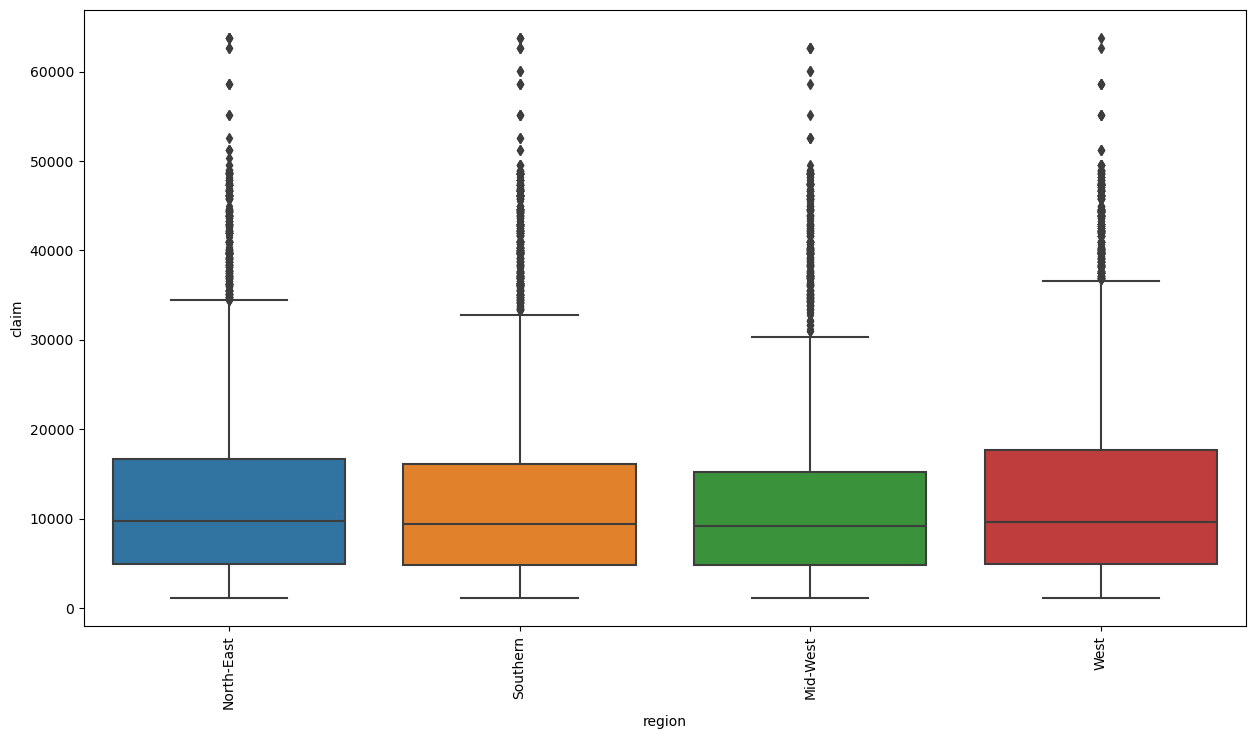

In [33]:
# set figure size
plt.figure(figsize=(15,8))
ax = sns.boxplot(x="region", y="claim", data=df_insurance)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
plt.show()

The plot shows that there is not much significant difference in the variance of the insurance claim across the regions.

<a id='outliers'></a>
### 4.1.9 Discover Outliers

**1. Plot boxplot for numerical data**

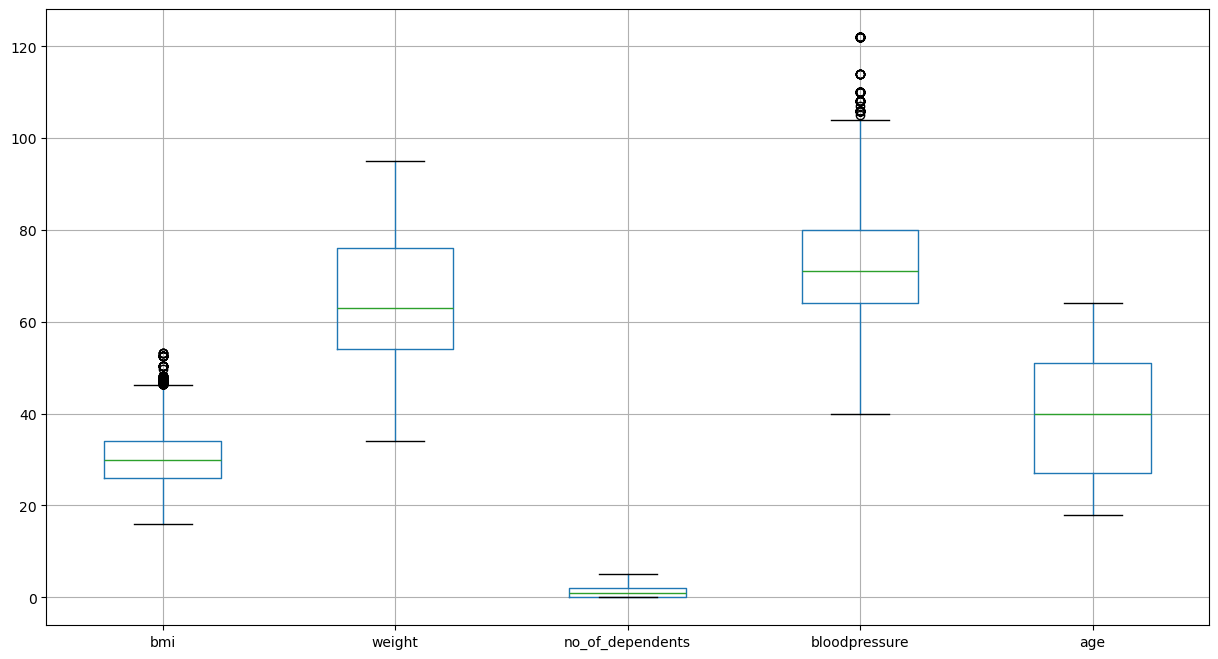

In [34]:
plt.rcParams['figure.figsize']=(15,8)
df_numeric_features.boxplot(column=['bmi', 'weight','no_of_dependents', 'bloodpressure', 'age'])
plt.show()

**2. Note the variables for which outliers are present**

From the above plot, we notice that for the variable 'bmi' and 'bloodpressure' contain outliers

**3. Remove outliers by IQR method**

In [141]:
# calculate interquartile range 

# compute the first quartile using quantile(0.25)
# use .drop() to drop the target variable 
Q1 = df_numeric_features.drop(['claim'], axis=1).quantile(0.25)

# compute the first quartile using quantile(0.75)
# use .drop() to drop the target variable 
Q3 = df_numeric_features.drop(['claim'], axis=1).quantile(0.75)

# calculate of interquartile range 
IQR = Q3 - Q1
print(IQR)
print('*/'*75)
print(Q1)
print('*/'*75)
print(Q3)

age                1.73
weight             1.54
bmi                1.41
no_of_dependents   1.64
bloodpressure      1.31
log_claim          1.23
dtype: float64
*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
age                -0.91
weight             -0.79
bmi                -0.74
no_of_dependents   -0.92
bloodpressure      -0.74
log_claim           8.49
Name: 0.25, dtype: float64
*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
age                0.82
weight             0.75
bmi                0.67
no_of_dependents   0.72
bloodpressure      0.57
log_claim          9.72
Name: 0.75, dtype: float64


In [3]:
# Calculate Q1, Q3, and IQR for specified columns
Q1 = df_insurance[['age', 'weight', 'bmi', 'no_of_dependents', 'bloodpressure']].quantile(0.25)
Q3 = df_insurance[['age', 'weight', 'bmi', 'no_of_dependents', 'bloodpressure']].quantile(0.75)
IQR = Q3 - Q1

# Define outlier condition for each column
outlier_condition = ((df_insurance[['age', 'weight', 'bmi', 'no_of_dependents', 'bloodpressure']] < (Q1 - 1.5 * IQR)) | 
                     (df_insurance[['age', 'weight', 'bmi', 'no_of_dependents', 'bloodpressure']] > (Q3 + 1.5 * IQR)))

# Filter rows where any of the outlier conditions is true
df_insurance_cleaned = df_insurance[~outlier_condition.any(axis=1)]

NameError: name 'df_insurance' is not defined

A simple way to know whether the outliers have been removed or not is to check the dimensions of the data. 

There is a reduction in the number of rows(from 15000 to 14723).

**4. Plot boxplot to recheck for outliers**

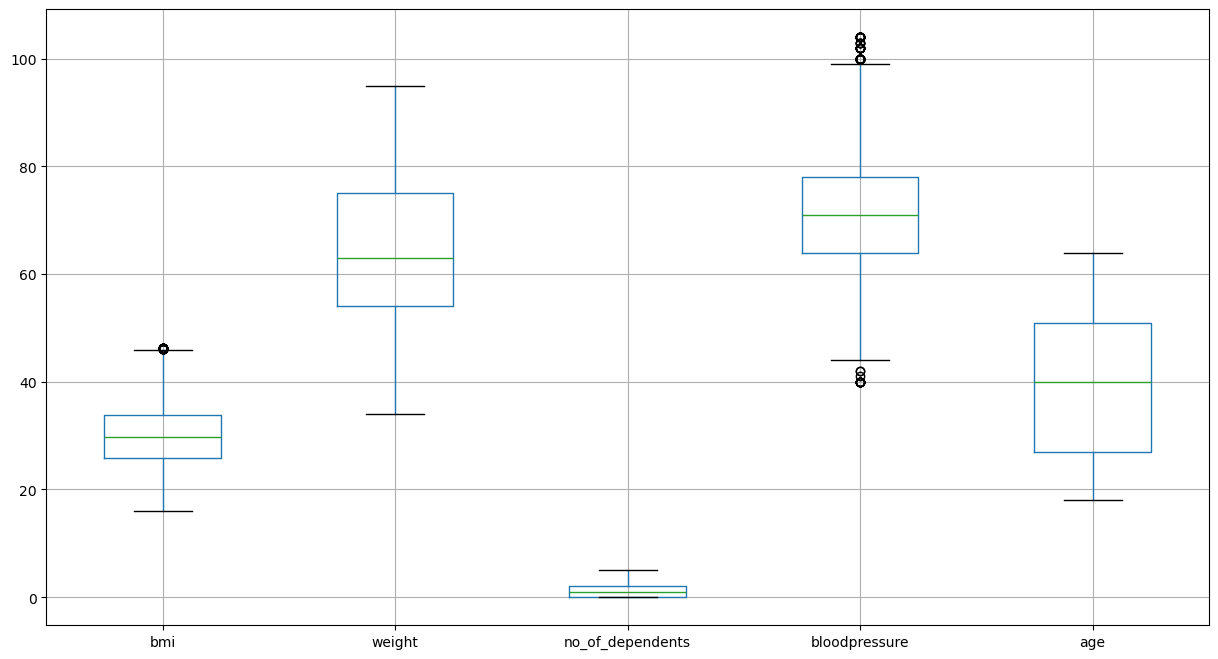

In [37]:
plt.rcParams['figure.figsize']=(15,8)

df_insurance.boxplot(column=['bmi', 'weight','no_of_dependents', 'bloodpressure', 'age'])
plt.show()

Observing the range of the boxplot, we say that the outliers are removed from the original data. The new 'outliers' that you see are moderate outliers that lie within the min/max range before removing the actual outliers

### 4.1.10 Recheck the Correlation

In [143]:
df_numeric_features = df_insurance.select_dtypes(include=np.number)
df_numeric_features.columns

Index(['age', 'weight', 'bmi', 'no_of_dependents', 'bloodpressure', 'claim'], dtype='object')

In [144]:

corr =  df_numeric_features.corr()

# print the correlation matrix
corr

,age,weight,bmi,no_of_dependents,bloodpressure,claim
age,1.00,0.29,0.19,0.06,-0.01,0.30
weight,0.29,1.00,0.25,0.14,-0.02,0.08
bmi,0.19,0.25,1.00,0.05,-0.04,0.21
no_of_dependents,0.06,0.14,0.05,1.00,0.02,0.07
bloodpressure,-0.01,-0.02,-0.04,0.02,1.00,0.01
claim,0.30,0.08,0.21,0.07,0.01,1.00


**3. Pass the correlation matrix to the heatmap() function of the seaborn library to plot the heatmap of the correlation matrix**

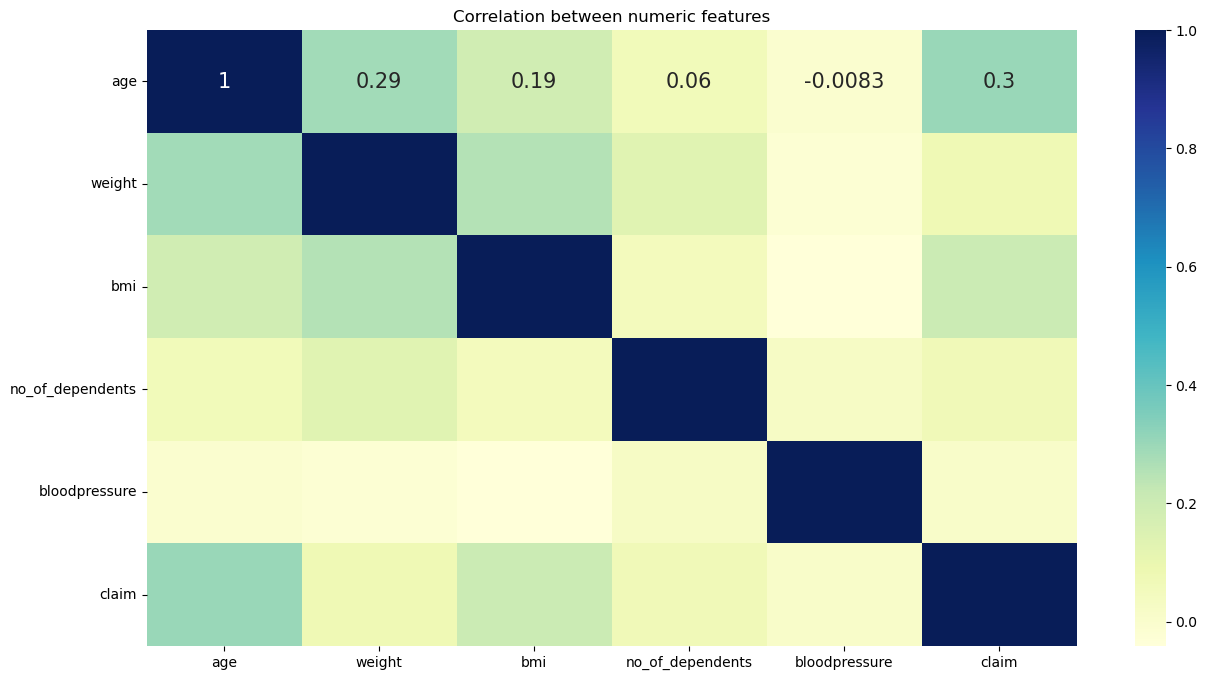

In [145]:
plt.figure(figsize=(15, 8))

sns.heatmap(corr, cmap='YlGnBu', annot = True, annot_kws={"size": 15})
plt.title('Correlation between numeric features')
plt.show()